# Dependency Installation and Imports

In [ ]:
!pip install opencv-python mediapipe==0.10.14 matplotlib seaborn tensorflow scikit-learn tensorflowjs

In [1]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 1.8 MB/s  0:00:002.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 1.0 MB/s  0:00:021.3 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]━━━━━━━ 2/3 [ipywidgets]

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [12]:
# %%
import cv2
import mediapipe as mp
import numpy as np
import os
from time import time

# Data Collection

In [13]:
# %%
GESTURE_CLASSES = ["A","B","C","D","E","F","G","H","I","K","L","M","N","O","P","Q","R","S","T","U","V","W","X","Y", "Unknown"]
DATA_PATH = "static_dataset"
SAMPLES_PER_GESTURE = 300
CENTER_BY_WRIST = True
FLATTEN = True
INCLUDE_HANDEDNESS = True

os.makedirs(DATA_PATH, exist_ok=True)
for g in GESTURE_CLASSES:
    os.makedirs(os.path.join(DATA_PATH,g), exist_ok=True)

mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils
hands = mp_hands.Hands(static_image_mode=False, max_num_hands=1,
                       min_detection_confidence=0.7,
                       min_tracking_confidence=0.7)

cap = cv2.VideoCapture(0)

for gesture in GESTURE_CLASSES:
    print(f"Collecting: {gesture}")
    count = 0
    while count < SAMPLES_PER_GESTURE:
        ret, frame = cap.read()
        if not ret:
            continue

        frame = cv2.flip(frame,1)
        rgb = cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)
        result = hands.process(rgb)

        keypoints = None
        if result.multi_hand_landmarks:
            lm = result.multi_hand_landmarks[0]
            mp_draw.draw_landmarks(frame, lm, mp_hands.HAND_CONNECTIONS)
            pts = np.array([[p.x,p.y,p.z] for p in lm.landmark])
            if CENTER_BY_WRIST:
                pts -= pts[0]
            if FLATTEN:
                pts = pts.flatten()
            if INCLUDE_HANDEDNESS and result.multi_handedness:
                handlabel = result.multi_handedness[0].classification[0].label
                pts = np.append(pts, 0 if handlabel=="Left" else 1)
            keypoints = pts

        cv2.putText(frame,f"{gesture} {count}/{SAMPLES_PER_GESTURE}",(10,30),
                    cv2.FONT_HERSHEY_SIMPLEX,0.7,(0,255,0),2)
        cv2.imshow("Collect Gestures", frame)
        k = cv2.waitKey(1) & 0xFF

        if k==ord("c") and keypoints is not None:
            np.save(os.path.join(DATA_PATH,gesture,f"{count:03d}.npy"), keypoints)
            count +=1

        if k==ord("q"):
            break

cap.release()
cv2.destroyAllWindows()
print("Done collecting!")

I0000 00:00:1773555000.752613   10362 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1773555000.756878   48678 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 620 (WHL GT2)
W0000 00:00:1773555000.778604   48670 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773555000.811546   48672 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Collecting: A
Collecting: B
Collecting: C
Collecting: D
Collecting: E
Collecting: F
Collecting: G
Collecting: H
Collecting: I
Collecting: K
Collecting: L
Collecting: M
Collecting: N
Collecting: O
Collecting: P
Collecting: Q
Collecting: R
Collecting: S
Collecting: T
Collecting: U
Collecting: V
Collecting: W
Collecting: X
Collecting: Y
Collecting: Unknown
Done collecting!


# Data Splitting and Preprocessing

In [14]:
# %%
import os
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns

# Load
X,y = [],[]
for i,gesture in enumerate(GESTURE_CLASSES):
    folder = os.path.join(DATA_PATH,gesture)
    for f in os.listdir(folder):
        X.append(np.load(os.path.join(folder,f)))
        y.append(i)

X,y = np.array(X),np.array(y)
y = to_categorical(y,len(GESTURE_CLASSES))

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("Train:",X_train.shape,"Test:",X_test.shape)

Train: (6000, 64) Test: (1500, 64)


In [15]:
# %%
# Build MLP
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(len(GESTURE_CLASSES), activation='softmax')
])

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

/home/bennybun29/Documents/jupyter_projects/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 25)             │         1,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,201 (71.10 KB)

 Trainable params: 18,201 (71.10 KB)

 Non-trainable params: 0 (0.00 B)

# Training

In [16]:
# %%
history = model.fit(X_train,y_train, validation_data=(X_test,y_test),
                    epochs=50, batch_size=16)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2472 - loss: 2.5150 - val_accuracy: 0.6507 - val_loss: 1.5516
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5777 - loss: 1.3075 - val_accuracy: 0.8053 - val_loss: 0.8205
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7193 - loss: 0.8665 - val_accuracy: 0.8700 - val_loss: 0.5658
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7757 - loss: 0.6807 - val_accuracy: 0.8760 - val_loss: 0.4409
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8070 - loss: 0.5687 - val_accuracy: 0.8913 - val_loss: 0.3849
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8407 - loss: 0.4938 - val_accuracy: 0.9013 - val_loss: 0.3445
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8603 - loss: 0.4274 - val_accuracy: 0.9233 - val_loss: 0.3059
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8747 - loss: 0.3795 - val_accuracy: 0.

NORMAL TEST
Accuracy: 0.992
Recall:   0.9917306158952206
F1:       0.9919479491674997
MSE:      0.12


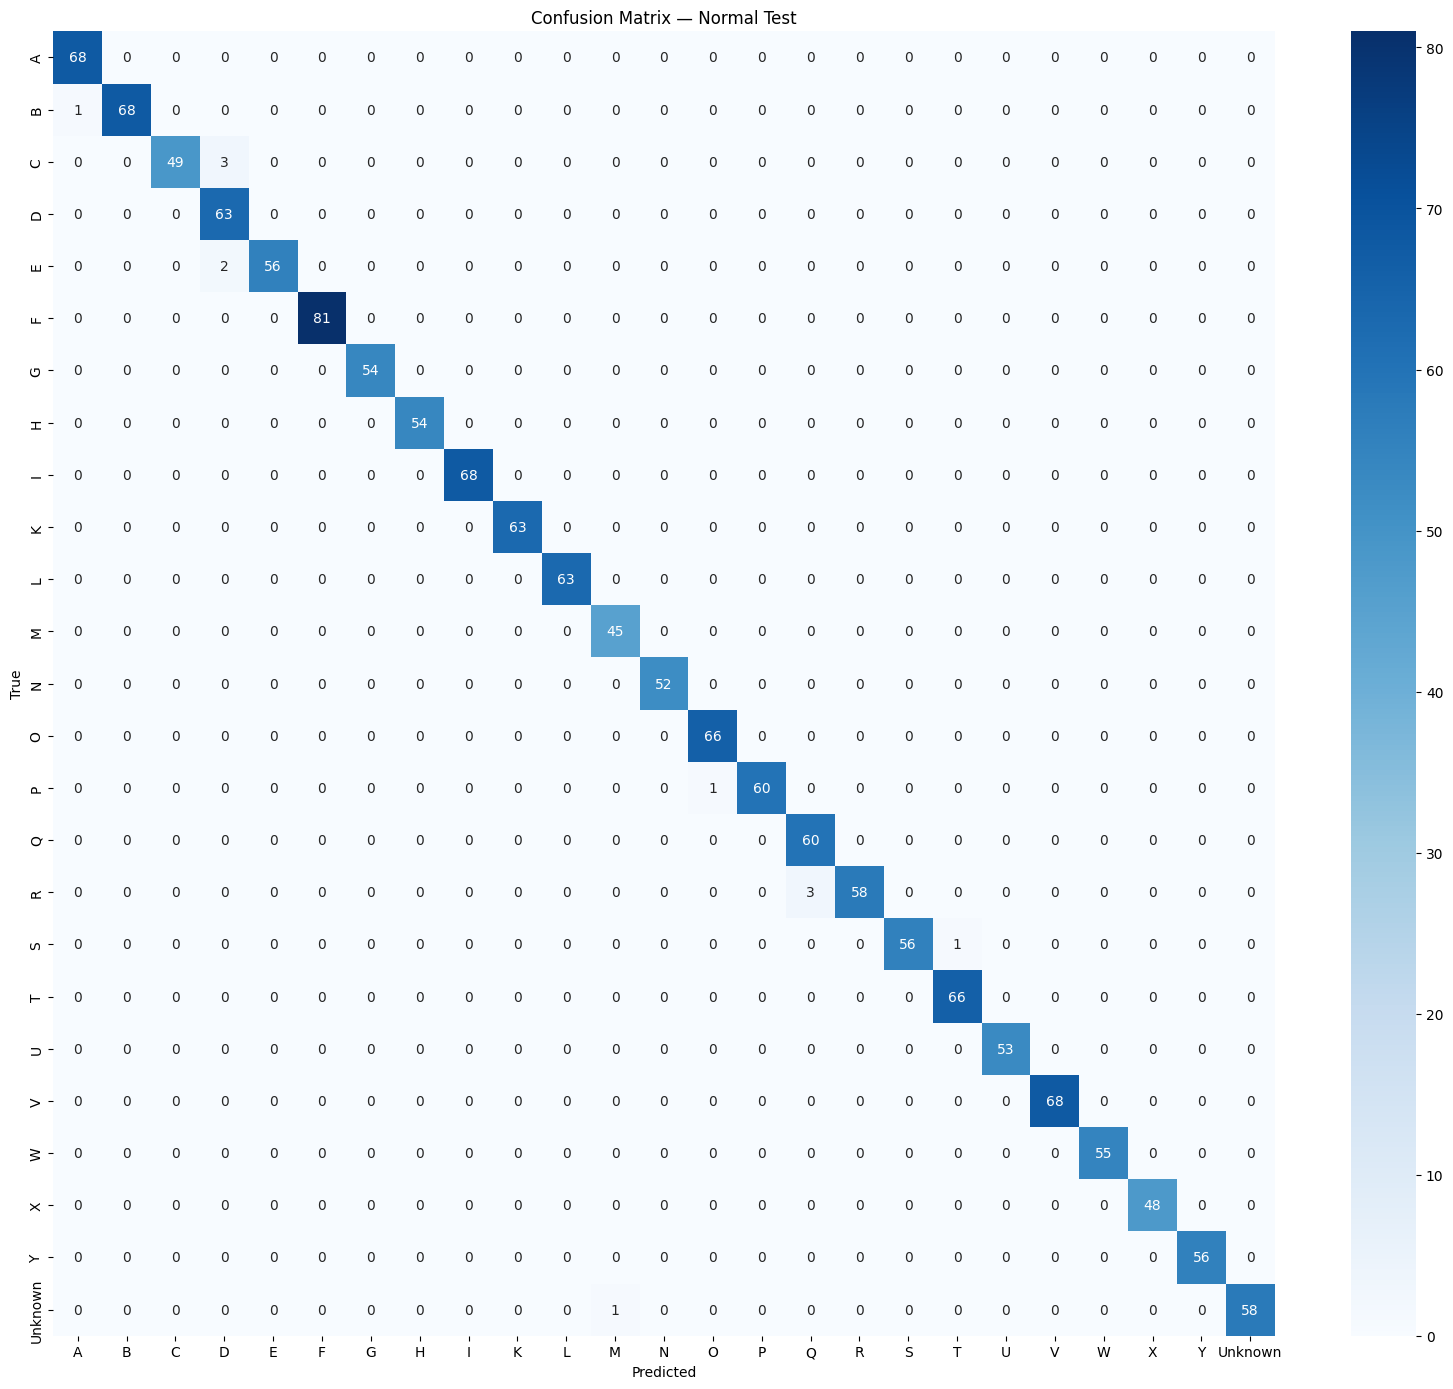

In [22]:
y_pred_probs = infer(**{input_key: tf.convert_to_tensor(X_test, dtype=tf.float32)})
y_pred = np.argmax(list(y_pred_probs.values())[0].numpy(), axis=1)
y_true = np.argmax(y_test, axis=1)

from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, mean_squared_error

acc = accuracy_score(y_true, y_pred)
rec = recall_score(y_true, y_pred, average='macro')
f1  = f1_score(y_true, y_pred, average='macro')
mse = mean_squared_error(y_true, y_pred)

print("NORMAL TEST")
print("Accuracy:", acc)
print("Recall:  ", rec)
print("F1:      ", f1)
print("MSE:     ", mse)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GESTURE_CLASSES,
            yticklabels=GESTURE_CLASSES)
plt.title("Confusion Matrix — Normal Test")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [ ]:
# Model Export and TFJS / TFLite conversion

In [18]:
model.export("saved_model_new")
print("SavedModel export complete!")

INFO:tensorflow:Assets written to: saved_model_new/assets


INFO:tensorflow:Assets written to: saved_model_new/assets


Saved artifact at 'saved_model_new'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64), dtype=tf.float32, name='keras_tensor_6')
Output Type:
  TensorSpec(shape=(None, 25), dtype=tf.float32, name=None)
Captures:
  138146590543888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138146590542736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138146575896784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138146575896016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138146575896208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138146575905616: TensorSpec(shape=(), dtype=tf.resource, name=None)
SavedModel export complete!


In [ ]:
# Go to google colab to convert to tfjs_model
# !pip install tensorflowjs
# !tensorflowjs_converter --input_format=tf_saved_model --output_format=tfjs_graph_model saved_model_new tfjs_model_new

In [12]:
# %%
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_saved_model("saved_model_new")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open("gesture_model_new.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model saved!")

TFLite model saved!


W0000 00:00:1772105954.186678    7541 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1772105954.186764    7541 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-02-26 19:39:14.187979: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: saved_model_new
2026-02-26 19:39:14.191110: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-02-26 19:39:14.191242: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: saved_model_new
I0000 00:00:1772105954.212301    7541 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
2026-02-26 19:39:14.216087: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-02-26 19:39:14.302791: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: saved_model_new
2026-02-26 19:39:14.317670: I tensorflow/cc/saved_model/loader.cc:471] SavedModel loa

# Edge Case Testing — Live Camera (OpenCV + MediaPipe)

Each test opens your webcam, runs the full pipeline (camera → MediaPipe → model), and records:
- **Predicted label** and **confidence %**
- **Per-frame latency** (MediaPipe + inference combined)
- **Frame log** saved to a CSV at the end

### Controls (same for all tests)
| Key | Action |
|-----|--------|
| `s` | Save current frame result to log |
| `q` | Quit test and print summary |

---
> **Run the shared setup cell first**, then run any test independently.


In [19]:
import cv2
import mediapipe as mp
import numpy as np
import csv
import os
import threading
import ipywidgets as widgets
from IPython.display import display
from time import time
from datetime import datetime
import tensorflow as tf

GESTURE_CLASSES = ["A","B","C","D","E","F","G","H","I","K","L","M",
                   "N","O","P","Q","R","S","T","U","V","W","X","Y","Unknown"]
CONFIDENCE_THRESHOLD = 0.95

# Load model from saved export
model = tf.saved_model.load("saved_model_new")
infer = model.signatures["serving_default"]
input_key = list(infer.structured_input_signature[1].keys())[0]
print(f"Model loaded. Input key: {input_key}")

mp_hands = mp.solutions.hands
mp_draw  = mp.solutions.drawing_utils

def extract_keypoints(frame, hands_model):
    rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    result = hands_model.process(rgb)
    if not result.multi_hand_landmarks:
        return None, frame, False
    lm  = result.multi_hand_landmarks[0]
    mp_draw.draw_landmarks(frame, lm, mp_hands.HAND_CONNECTIONS)
    pts = np.array([[p.x, p.y, p.z] for p in lm.landmark])
    pts -= pts[0]
    pts  = pts.flatten()
    if result.multi_handedness:
        hl  = result.multi_handedness[0].classification[0].label
        pts = np.append(pts, 0 if hl == "Left" else 1)
    return pts, frame, True

def run_inference(keypoints):
    x      = tf.convert_to_tensor(keypoints.reshape(1, -1), dtype=tf.float32)
    t0     = time()
    out    = infer(**{input_key: x})
    probs  = list(out.values())[0].numpy()[0]
    lat_ms = (time() - t0) * 1000

    idx        = int(np.argmax(probs))
    confidence = float(probs[idx])
    label      = GESTURE_CLASSES[idx] if confidence >= CONFIDENCE_THRESHOLD else "Unknown"
    return label, confidence, lat_ms
    
def save_csv(log, filename):
    if not log:
        return
    with open(filename, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=log[0].keys())
        writer.writeheader()
        writer.writerows(log)
    print(f"  Saved → {filename}")

def print_summary(log, test_name):
    if not log:
        print("  No frames recorded.")
        return
    latencies = [r["latency_ms"] for r in log]
    detected  = sum(1 for r in log if r["hand_detected"])
    unknown   = sum(1 for r in log if r["predicted_label"] in ("Unknown", "N/A — no hand", "—"))
    valid_lat = [l for l in latencies if l > 0]
    print(f"\n{'='*55}")
    print(f"  {test_name} — Summary")
    print(f"{'='*55}")
    print(f"  Frames recorded    : {len(log)}")
    print(f"  Hand detected      : {detected} / {len(log)}")
    print(f"  Unknown/low conf   : {unknown} / {len(log)}")
    if valid_lat:
        print(f"  --- Latency (ms) ---")
        print(f"  Avg : {np.mean(valid_lat):.3f}")
        print(f"  Min : {np.min(valid_lat):.3f}")
        print(f"  Max : {np.max(valid_lat):.3f}")
        print(f"  p95 : {np.percentile(valid_lat, 95):.3f}")
    print(f"{'='*55}\n")

def draw_hud(frame, lines, colors):
    for i, (text, color) in enumerate(zip(lines, colors)):
        cv2.putText(frame, text, (10, 30 + i*30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

def encode_frame(frame):
    _, buf = cv2.imencode(".jpg", frame, [cv2.IMWRITE_JPEG_QUALITY, 80])
    return bytes(buf)

print("Shared setup ready. ✓")


Model loaded. Input key: keras_tensor_6
Shared setup ready. ✓


---
## Test 1 — Normal Input
**What it tests:** Full pipeline with a real hand showing a letter from the dataset.  
**Expected:** Correct letter predicted, confidence ≥ 85 %, low stable latency.  
**Controls:** Click **[Save Frame]** to log a result · Click **[Quit]** to stop.


In [20]:
TEST_NAME = "Test 1 — Normal Input"
LOG_FILE  = "test1_normal_input.csv"
log       = []
_running  = [True]

# ── Widgets ───────────────────────────────────────────────────────────────────
img_out    = widgets.Image(format="jpeg", width=640, height=480)
status_out = widgets.Output()
btn_save   = widgets.Button(description="💾 Save Frame", button_style="success")
btn_quit   = widgets.Button(description="⏹ Quit",        button_style="danger")

display(widgets.VBox([
    widgets.HTML(f"<h3>{TEST_NAME}</h3>"),
    img_out,
    widgets.HBox([btn_save, btn_quit]),
    status_out
]))

def on_quit(b):
    _running[0] = False
btn_quit.on_click(on_quit)

# Shared state for save button
_last = {"label": "—", "conf": 0.0, "lat_ms": 0.0,
         "total_ms": 0.0, "hand": False}

def on_save(b):
    entry = {
        "timestamp":       datetime.now().isoformat(),
        "test":            TEST_NAME,
        "hand_detected":   _last["hand"],
        "predicted_label": _last["label"],
        "confidence":      round(_last["conf"], 4),
        "latency_ms":      round(_last["lat_ms"], 3),
        "total_frame_ms":  round(_last["total_ms"], 3),
    }
    log.append(entry)
    with status_out:
        print(f"  Saved: {_last['label']} ({_last['conf']*100:.1f}%) — {_last['lat_ms']:.2f} ms")
btn_save.on_click(on_save)

# ── Camera loop ───────────────────────────────────────────────────────────────
def camera_loop():
    hands_model = mp_hands.Hands(static_image_mode=False, max_num_hands=1,
                                 min_detection_confidence=0.7, min_tracking_confidence=0.7)
    cap = cv2.VideoCapture(0)
    while _running[0]:
        ret, frame = cap.read()
        if not ret:
            continue
        frame = cv2.flip(frame, 1)
        t0    = time()

        kp, frame, hand_found = extract_keypoints(frame, hands_model)
        label, conf, lat_ms   = "—", 0.0, 0.0

        if hand_found and kp is not None:
            label, conf, lat_ms = run_inference(kp)

        total_ms = (time() - t0) * 1000
        _last.update({"label": label, "conf": conf, "lat_ms": lat_ms,
                      "total_ms": total_ms, "hand": hand_found})

        color = (0,255,0) if conf >= CONFIDENCE_THRESHOLD else (0,165,255)
        draw_hud(frame,
            [f"Pred : {label}", f"Conf : {conf*100:.1f}%",
             f"Lat  : {lat_ms:.1f} ms", f"Total: {total_ms:.1f} ms",
             "Click [Save Frame] or [Quit]"],
            [color, color, (255,255,255), (200,200,200), (180,180,180)])

        img_out.value = encode_frame(frame)

    cap.release()
    hands_model.close()
    if log:
        save_csv(log, LOG_FILE)
    print_summary(log, TEST_NAME)

t = threading.Thread(target=camera_loop, daemon=True)
t.start()


I0000 00:00:1773555777.817463   63738 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1773555777.822783   63749 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 620 (WHL GT2)
W0000 00:00:1773555777.842035   63741 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773555777.867521   63742 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/home/bennybun29/Documents/jupyter_projects/.venv/lib/python3.12/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


---
## Test 2 — No Input (Empty Frame)
**What it tests:** Pipeline behaviour when no hand is in frame.  
**Expected:** MediaPipe detects nothing, model is never called, no crash.  
**Controls:** Keep hand OUT of frame · **[Save Frame]** to log · **[Quit]** to stop.


In [20]:
TEST_NAME = "Test 2 — No Input"
LOG_FILE  = "test2_no_input.csv"
log       = []
_running  = [True]

img_out    = widgets.Image(format="jpeg", width=640, height=480)
status_out = widgets.Output()
btn_save   = widgets.Button(description="💾 Save Frame", button_style="success")
btn_quit   = widgets.Button(description="⏹ Quit",        button_style="danger")

display(widgets.VBox([
    widgets.HTML(f"<h3>{TEST_NAME}</h3>"),
    img_out,
    widgets.HBox([btn_save, btn_quit]),
    status_out
]))

def on_quit(b):
    _running[0] = False
btn_quit.on_click(on_quit)

_last = {"hand": False, "total_ms": 0.0}

def on_save(b):
    entry = {
        "timestamp":       datetime.now().isoformat(),
        "test":            TEST_NAME,
        "hand_detected":   _last["hand"],
        "predicted_label": "N/A — no hand" if not _last["hand"] else "Hand detected!",
        "confidence":      0.0,
        "latency_ms":      0.0,
        "total_frame_ms":  round(_last["total_ms"], 3),
    }
    log.append(entry)
    with status_out:
        status = "No hand" if not _last["hand"] else "⚠ Hand detected!"
        print(f"  Saved: {status} — frame {_last['total_ms']:.2f} ms")
btn_save.on_click(on_save)

def camera_loop():
    hands_model = mp_hands.Hands(static_image_mode=False, max_num_hands=1,
                                 min_detection_confidence=0.7, min_tracking_confidence=0.7)
    cap = cv2.VideoCapture(0)
    while _running[0]:
        ret, frame = cap.read()
        if not ret:
            continue
        frame    = cv2.flip(frame, 1)
        t0       = time()
        _, frame, hand_found = extract_keypoints(frame, hands_model)
        total_ms = (time() - t0) * 1000
        _last.update({"hand": hand_found, "total_ms": total_ms})

        status = "⚠ Hand detected!" if hand_found else "No hand detected"
        color  = (0,0,255) if hand_found else (0,200,255)
        draw_hud(frame,
            [status, f"Total: {total_ms:.1f} ms", "Click [Save Frame] or [Quit]"],
            [color, (200,200,200), (180,180,180)])

        img_out.value = encode_frame(frame)

    cap.release()
    hands_model.close()
    if log:
        save_csv(log, LOG_FILE)
    print_summary(log, TEST_NAME)

t = threading.Thread(target=camera_loop, daemon=True)
t.start()


I0000 00:00:1773069817.322692   78701 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1773069817.325005   78712 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 620 (WHL GT2)
W0000 00:00:1773069817.337698   78703 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773069817.355805   78703 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


---
## Test 3 — Unknown / Out-of-Distribution Input
**What it tests:** Model behaviour on gestures NOT in the dataset (J, Z, thumbs up, fist, etc.).  
**Expected:** Confidence < 85 % → flagged "Unknown". High confidence on unknown = needs lower threshold.  
**Controls:** Show gestures NOT in dataset · **[Save Frame]** to log · **[Quit]** to stop.


In [21]:
TEST_NAME = "Test 3 — Unknown Input"
LOG_FILE  = "test3_unknown_input.csv"
log       = []
_running  = [True]

img_out    = widgets.Image(format="jpeg", width=640, height=480)
status_out = widgets.Output()
btn_save   = widgets.Button(description="💾 Save Frame", button_style="success")
btn_quit   = widgets.Button(description="⏹ Quit",        button_style="danger")

display(widgets.VBox([
    widgets.HTML(f"<h3>{TEST_NAME}</h3>"),
    img_out,
    widgets.HBox([btn_save, btn_quit]),
    status_out
]))

def on_quit(b):
    _running[0] = False
btn_quit.on_click(on_quit)

_last = {"raw": "—", "label": "—", "conf": 0.0,
         "lat_ms": 0.0, "total_ms": 0.0, "hand": False}

def on_save(b):
    entry = {
        "timestamp":           datetime.now().isoformat(),
        "test":                TEST_NAME,
        "hand_detected":       _last["hand"],
        "raw_predicted_label": _last["raw"],
        "predicted_label":     _last["label"],
        "confidence":          round(_last["conf"], 4),
        "confidently_wrong":   _last["hand"] and _last["label"] != "Unknown",
        "latency_ms":          round(_last["lat_ms"], 3),
        "total_frame_ms":      round(_last["total_ms"], 3),
    }
    log.append(entry)
    with status_out:
        flag = "⚠ CONFIDENTLY WRONG" if entry["confidently_wrong"] else "✓ Unknown"
        print(f"  Saved: raw={_last['raw']} → {_last['label']} ({_last['conf']*100:.1f}%) {flag} — {_last['lat_ms']:.2f} ms")
btn_save.on_click(on_save)

def camera_loop():
    hands_model = mp_hands.Hands(static_image_mode=False, max_num_hands=1,
                                 min_detection_confidence=0.7, min_tracking_confidence=0.7)
    cap = cv2.VideoCapture(0)
    while _running[0]:
        ret, frame = cap.read()
        if not ret:
            continue
        frame = cv2.flip(frame, 1)
        t0    = time()

        kp, frame, hand_found = extract_keypoints(frame, hands_model)
        raw_label, label, conf, lat_ms = "—", "—", 0.0, 0.0

        if hand_found and kp is not None:
            x      = tf.convert_to_tensor(kp.reshape(1,-1), dtype=tf.float32)
            ti     = time()
            out = infer(**{input_key: x})
            probs  = list(out.values())[0].numpy()[0]
            lat_ms = (time() - ti) * 1000
            idx       = int(np.argmax(probs))
            conf      = float(probs[idx])
            raw_label = GESTURE_CLASSES[idx]
            label     = raw_label if conf >= CONFIDENCE_THRESHOLD else "Unknown"

        total_ms = (time() - t0) * 1000
        _last.update({"raw": raw_label, "label": label, "conf": conf,
                      "lat_ms": lat_ms, "total_ms": total_ms, "hand": hand_found})

        # Red = confidently wrong, Green = correctly unknown
        is_safe = (label == "Unknown" or not hand_found)
        color   = (0,255,0) if is_safe else (0,0,255)
        draw_hud(frame,
            [f"Raw  : {raw_label}", f"Result: {label}",
             f"Conf : {conf*100:.1f}%", f"Lat  : {lat_ms:.1f} ms",
             f"Total: {total_ms:.1f} ms", "Click [Save Frame] or [Quit]"],
            [(200,200,200), color, color, (255,255,255), (200,200,200), (180,180,180)])

        img_out.value = encode_frame(frame)

    cap.release()
    hands_model.close()
    if log:
        save_csv(log, LOG_FILE)
    confidently_wrong = [r for r in log if r.get("confidently_wrong")]
    print_summary(log, TEST_NAME)
    if confidently_wrong:
        print(f"  ⚠  CONFIDENTLY WRONG frames : {len(confidently_wrong)}")
        print(f"     Lower CONFIDENCE_THRESHOLD or add a rejection class.")
    elif log:
        print(f"  ✓  All unknown gestures correctly flagged.")

t = threading.Thread(target=camera_loop, daemon=True)
t.start()


I0000 00:00:1773069844.994519   78971 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1773069844.996943   78982 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 620 (WHL GT2)
W0000 00:00:1773069845.009477   78974 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773069845.028061   78972 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


---
## Combined Results Summary
Run this after completing all three tests to see a unified latency + outcome table.


In [ ]:
import csv
import numpy as np

files = {
    "Test 1 — Normal Input":   "test1_normal_input.csv",
    "Test 2 — No Input":       "test2_no_input.csv",
    "Test 3 — Unknown Input":  "test3_unknown_input.csv",
}

print(f"{'Test':<28} {'Frames':>7} {'Detected':>9} {'Unknown':>9} {'Avg ms':>8} {'Max ms':>8} {'p95 ms':>8}")
print("-" * 82)

for name, path in files.items():
    if not os.path.exists(path):
        print(f"{name:<28}  — file not found, skip")
        continue

    with open(path) as f:
        rows = list(csv.DictReader(f))

    if not rows:
        print(f"{name:<28}  — empty log")
        continue

    latencies = [float(r["latency_ms"]) for r in rows]
    detected  = sum(1 for r in rows if r["hand_detected"] in ("True","1","true"))
    unknown   = sum(1 for r in rows if r["predicted_label"] in ("Unknown","N/A — no hand","—"))

    # exclude zero-latency (no-hand) frames from latency stats
    valid_lat = [l for l in latencies if l > 0]
    avg = np.mean(valid_lat) if valid_lat else 0
    mx  = np.max(valid_lat)  if valid_lat else 0
    p95 = np.percentile(valid_lat, 95) if valid_lat else 0

    print(f"{name:<28} {len(rows):>7} {detected:>9} {unknown:>9} {avg:>8.2f} {mx:>8.2f} {p95:>8.2f}")

print("-" * 82)
print("Latency = model inference only (ms). Total frame time includes MediaPipe.")
